# MNIST MLP model (using only math packages)

Shape: (60000, 28, 28), Dtype: uint8


Text(0.5, 1.0, '5')

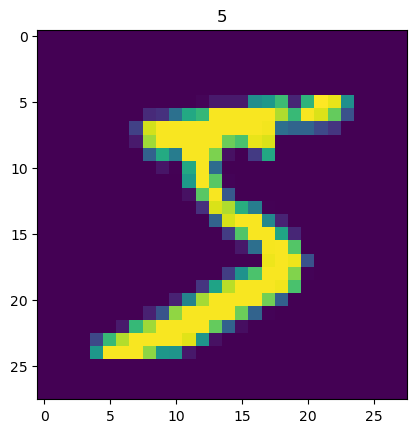

In [11]:
import numpy as np
from keras.datasets import mnist
import matplotlib.pyplot as plt


# Get data
(x_train, y_train), (x_test, y_test) = mnist.load_data()

print(f"Shape: {x_train.shape}, Dtype: {x_train.dtype}")
plt.imshow(x_train[0])
plt.title(y_train[0])

## Normalizing data

In [5]:
from sklearn.preprocessing import OneHotEncoder

x_train = x_train / 255
x_test = x_test / 255
y_train = y_train.reshape(-1, 1)

x_train = x_train.reshape(-1, 784)
x_test = x_test.reshape(-1, 784)
print(f"x_train shape: {x_train.shape}")

encoder = OneHotEncoder(sparse_output=False, categories="auto")
y_train_encoded = encoder.fit_transform(y_train)
print(y_train_encoded[2])

x_train shape: (60000, 784)
[0. 0. 0. 0. 1. 0. 0. 0. 0. 0.]


## Neural Network class

In [6]:
class Network:
    def __init__(self, layer_sizes: list[int]):
        self.layer_sizes = layer_sizes
        self.parameters = []

        for l in range(1, len(layer_sizes)):
            n_prev = layer_sizes[l-1]
            n_curr = layer_sizes[l]

            W_l = np.random.normal(loc=0, scale=np.sqrt(2 / n_prev), size=(n_curr, n_prev))
            self.parameters.append([W_l])

            b_l = np.zeros(shape=(n_curr, 1))
            self.parameters[-1].append(b_l)
        
        self.check_shapes()

    def check_shapes(self):
        assert self.parameters[0][0].shape == (self.layer_sizes[1], self.layer_sizes[0])
        assert self.parameters[0][1].shape == (self.layer_sizes[1], 1)

    def forward(self, X, learn=False):
        if learn:
            self.cache = []
        A = X
        num_layers = len(self.parameters)
        for l in range(num_layers):
            A_prev = A
            W, b = self.parameters[l][0], self.parameters[l][1]
            Z = np.matmul(W, A) + b
            if l != num_layers - 1:
                A = np.maximum(0, Z)
            else:
                A = Z
            if learn:
                self.cache.append([Z, A_prev])

        # softmax for last layer
        a_max = np.max(A, keepdims=True)
        e_a = np.exp(A - a_max)

        A_last = e_a / e_a.sum(keepdims=True)

        if learn:
            self.cache.append([A, self.cache[-1][1]])  # Сохраняем logits
            self.A_last = A_last

        assert np.isclose(np.sum(A_last), 1.0)
        
        return A_last
    
    def compute_loss(self, Y_true, Y_pred):
        epsilon = 1e-15

        Y_true = np.array(Y_true)
        Y_pred = np.array(Y_pred)
        
        m = Y_true.shape[1]
        loss = 0
        
        for i in range(m):
            log_pred = np.log(epsilon + Y_pred[:, i])
            loss += -np.sum(Y_true[:, i] * log_pred)
        loss = loss / m

        return loss

    def backward(self, Y_true, A_last):
        """
        Y_true: истинные метки (one-hot), форма (10, m)
        A_last: выход сети после Softmax, форма (10, m)
        """
        Y_true = np.array(Y_true)
        if Y_true.ndim == 1:
            Y_true = Y_true.reshape(-1, 1)
        
        A_last = np.array(A_last)
        if A_last.ndim == 1:
            A_last = A_last.reshape(-1, 1)
        
        m = Y_true.shape[1]
        grads = {}
        num_layers = len(self.parameters)
        
        # ============================================
        # ШАГ 1: Выходной слой
        # ============================================
        dZ = A_last - Y_true  # (10, m)
        
        Z_last, A_prev_last = self.cache[-1]
        
        # Гарантируем 2D форму
        if A_prev_last.ndim == 1:
            A_prev_last = A_prev_last.reshape(-1, 1)
        
        # dW = (1/m) * dZ @ A_prev.T
        grads['dW2'] = (1 / m) * np.matmul(dZ, A_prev_last.T)
        grads['db2'] = (1 / m) * np.sum(dZ, axis=1, keepdims=True)
        
        # ============================================
        # ШАГ 2: Скрытые слои
        # ============================================
        dA_prev = np.matmul(self.parameters[-1][0].T, dZ)
        
        for l in reversed(range(num_layers - 1)):
            Z, A_prev = self.cache[l]
            
            if A_prev.ndim == 1:
                A_prev = A_prev.reshape(-1, 1)
            
            # Производная ReLU
            dZ = dA_prev * (Z > 0)
            
            grads[f'dW{l+1}'] = (1 / m) * np.matmul(dZ, A_prev.T)
            grads[f'db{l+1}'] = (1 / m) * np.sum(dZ, axis=1, keepdims=True)
            
            if l > 0:
                dA_prev = np.matmul(self.parameters[l][0].T, dZ)
        
        return grads
    
    def update_parameters(self, grads, learning_rate):
        for l in range(len(self.parameters)):
            dw = grads[f'dW{l+1}']
            db = grads[f'db{l+1}']

            self.parameters[l][0] -= learning_rate * dw
            self.parameters[l][1] -= learning_rate * db

In [7]:
my_mlp = Network([784, 128, 10])

# Параметры обучения
learning_rate = 0.001
epochs = 100

for epoch in range(epochs):
    total_loss = 0
    
    # Проходим по всем примерам (для простоты - по одному)
    for i in range(len(x_train)):
        # 1. Подготовка данных
        X = x_train[i].reshape(-1, 1)  # (784, 1)
        Y = y_train_encoded[i].reshape(-1, 1)  # (10, 1)
        
        # 2. Forward pass
        A_last = my_mlp.forward(X, learn=True)
        
        # 3. Вычисление потерь
        loss = my_mlp.compute_loss(Y, A_last)
        total_loss += loss
        
        # 4. Backward pass
        grads = my_mlp.backward(Y, A_last)
        
        # 5. Обновление весов
        my_mlp.update_parameters(grads, learning_rate)
    
    # Вывод прогресса
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {total_loss / len(x_train):.4f}")

Epoch 0, Loss: 0.4220
Epoch 10, Loss: 0.0706
Epoch 20, Loss: 0.0375
Epoch 30, Loss: 0.0227
Epoch 40, Loss: 0.0146
Epoch 50, Loss: 0.0100
Epoch 60, Loss: 0.0072
Epoch 70, Loss: 0.0054
Epoch 80, Loss: 0.0043
Epoch 90, Loss: 0.0035


In [ ]:
result = my_mlp.forward(x_train[1].reshape(-1, 1))
print(np.argmax(result))

np.int64(0)